**Air Quality Classification using Machine Learning**



*   Built and compared multiple machine learning models (Logistic Regression,
Decision Tree, Random Forest, SVM, Naive Bayes)
*   Achieved high accuracy in predicting air pollution levels using environmental dataset


* Performed data preprocessing, feature engineering, and model evaluation using Python (Pandas, Scikit-learn, Matplotlib)

*   Identified Random Forest as the best-performing model















In [ ]:
#Write your code here
#Make sure to document it very well

In [ ]:
import numpy as np # linear algebra
import pandas as pd

data = pd.read_csv('Air Pollution.csv')

data.head()

,Country Name,City,Year,PM2.5 (μg/m3),PM10 (μg/m3),NO2 (μg/m3),PM25 temporal coverage (%),PM10 temporal coverage (%),NO2 temporal coverage (%),Updated Year
0,Afghanistan,Kabul,2019,119.77,NaN,NaN,18.0,NaN,NaN,2022
1,Albania,Durres,2015,NaN,17.65,26.63,NaN,NaN,83.961187,2022
2,Albania,Durres,2016,14.32,24.56,24.78,NaN,NaN,87.932605,2022
3,Albania,Elbasan,2015,NaN,NaN,23.96,NaN,NaN,97.853881,2022
4,Albania,Elbasan,2016,NaN,NaN,26.26,NaN,NaN,96.049636,2022


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32191 entries, 0 to 32190
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Country Name                32191 non-null  object 
 1   City                        32191 non-null  object 
 2   Year                        32191 non-null  int64  
 3   PM2.5 (μg/m3)               15048 non-null  float64
 4   PM10 (μg/m3)                21109 non-null  float64
 5   NO2 (μg/m3)                 22200 non-null  float64
 6   PM25 temporal coverage (%)  7275 non-null   float64
 7   PM10 temporal coverage (%)  5381 non-null   float64
 8   NO2 temporal coverage (%)   19890 non-null  float64
 9   Updated Year                32191 non-null  int64  
dtypes: float64(6), int64(2), object(2)
memory usage: 2.5+ MB


In [ ]:
data.max()

Country Name                  Viet Nam
City                          Živinice
Year                              2021
PM2.5 (μg/m3)                    191.9
PM10 (μg/m3)                     540.0
NO2 (μg/m3)                     210.68
PM25 temporal coverage (%)       100.0
PM10 temporal coverage (%)       100.0
NO2 temporal coverage (%)        100.0
Updated Year                      2022
dtype: object

In [ ]:
data.min()

Country Name                  Afghanistan
City                             A Coruna
Year                                 2000
PM2.5 (μg/m3)                        0.01
PM10 (μg/m3)                         1.04
NO2 (μg/m3)                           0.0
PM25 temporal coverage (%)            0.0
PM10 temporal coverage (%)       2.568493
NO2 temporal coverage (%)        1.923077
Updated Year                         2016
dtype: object

In [ ]:
data.isnull()

,Country Name,City,Year,PM2.5 (μg/m3),PM10 (μg/m3),NO2 (μg/m3),PM25 temporal coverage (%),PM10 temporal coverage (%),NO2 temporal coverage (%),Updated Year
0,False,False,False,False,True,True,False,True,True,False
1,False,False,False,True,False,False,True,True,False,False
2,False,False,False,False,False,False,True,True,False,False
3,False,False,False,True,True,False,True,True,False,False
4,False,False,False,True,True,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...
32186,False,False,False,True,False,True,True,True,True,False
32187,False,False,False,True,False,True,True,True,True,False
32188,False,False,False,True,False,True,True,True,True,False
32189,False,False,False,True,False,True,True,True,True,False


In [ ]:
data.isnull().sum()

Country Name                      0
City                              0
Year                              0
PM2.5 (μg/m3)                 17143
PM10 (μg/m3)                  11082
NO2 (μg/m3)                    9991
PM25 temporal coverage (%)    24916
PM10 temporal coverage (%)    26810
NO2 temporal coverage (%)     12301
Updated Year                      0
dtype: int64

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder # for convert the data to 0 or 1

labelencoder=LabelEncoder()

In [ ]:
object_list = data.select_dtypes(include='object').columns
for column in object_list:
    data[column]=labelencoder.fit_transform(data[column])#here convert the data to numeric list
    numeric_list = data.select_dtypes(include='float64').columns

In [ ]:
data

,Country Name,City,Year,PM2.5 (μg/m3),PM10 (μg/m3),NO2 (μg/m3),PM25 temporal coverage (%),PM10 temporal coverage (%),NO2 temporal coverage (%),Updated Year
0,0,2782,2019,119.77,NaN,NaN,18.0,NaN,NaN,2022
1,1,1613,2015,NaN,17.65,26.63,NaN,NaN,83.961187,2022
2,1,1613,2016,14.32,24.56,24.78,NaN,NaN,87.932605,2022
3,1,1667,2015,NaN,NaN,23.96,NaN,NaN,97.853881,2022
4,1,1667,2016,NaN,NaN,26.26,NaN,NaN,96.049636,2022
...,...,...,...,...,...,...,...,...,...,...
32186,117,4084,2013,NaN,30.00,NaN,NaN,NaN,NaN,2018
32187,117,4084,2014,NaN,12.00,NaN,NaN,NaN,NaN,2018
32188,117,4084,2015,NaN,14.00,NaN,NaN,NaN,NaN,2018
32189,117,6158,2013,NaN,27.00,NaN,NaN,NaN,NaN,2018


In [ ]:
object_list = data.select_dtypes(include='object').columns
for column in object_list:
    data[column]=labelencoder.fit_transform(data[column])#here convert the data to numeric list
    numeric_list = data.select_dtypes(include='float64').columns

for column in numeric_list:
    data[column].fillna(data[column].mean(), inplace=True)
category=['1','2', '3', '4', '5', '6']
data['Level']=pd.cut(data['PM10 (μg/m3)'], [0,54, 154, 254, 354, 424, 540], labels=category)# used to convert the continuous varible to categorial varible
data.head()
import matplotlib.pyplot as plt
level = data['Level'].value_counts()
print(level)
level = data['Level'].value_counts()
data = data.apply(pd.to_numeric)

1    30131
2     1817
3      215
4       22
6        4
5        2
Name: Level, dtype: int64


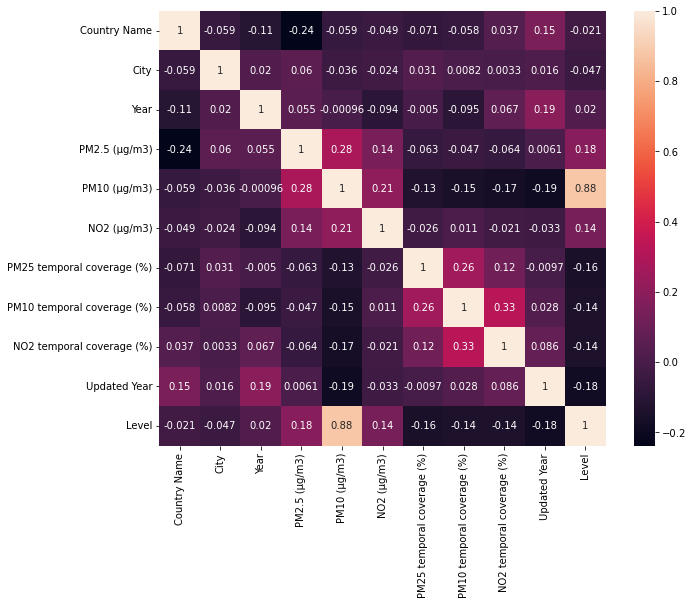

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot = True)
feature = data.drop('Level', axis=1)# axis 1 for culumn
target = data['Level']

In [ ]:
print(pd.cut(data['PM10 (μg/m3)'], [0,54, 154, 254, 354, 424, 540], labels=category))

0        1
1        1
2        1
3        1
4        1
        ..
32186    1
32187    1
32188    1
32189    1
32190    1
Name: PM10 (μg/m3), Length: 32191, dtype: category
Categories (6, object): ['1' < '2' < '3' < '4' < '5' < '6']


In [ ]:
data# show the data after drop city and contury and make new value is level1

,Country Name,City,Year,PM2.5 (μg/m3),PM10 (μg/m3),NO2 (μg/m3),PM25 temporal coverage (%),PM10 temporal coverage (%),NO2 temporal coverage (%),Updated Year,Level
0,0,2782,2019,119.77000,30.533252,20.619336,18.000000,90.5835,93.696804,2022,1
1,1,1613,2015,22.92032,17.650000,26.630000,90.794096,90.5835,83.961187,2022,1
2,1,1613,2016,14.32000,24.560000,24.780000,90.794096,90.5835,87.932605,2022,1
3,1,1667,2015,22.92032,30.533252,23.960000,90.794096,90.5835,97.853881,2022,1
4,1,1667,2016,22.92032,30.533252,26.260000,90.794096,90.5835,96.049636,2022,1
...,...,...,...,...,...,...,...,...,...,...,...
32186,117,4084,2013,22.92032,30.000000,20.619336,90.794096,90.5835,93.696804,2018,1
32187,117,4084,2014,22.92032,12.000000,20.619336,90.794096,90.5835,93.696804,2018,1
32188,117,4084,2015,22.92032,14.000000,20.619336,90.794096,90.5835,93.696804,2018,1
32189,117,6158,2013,22.92032,27.000000,20.619336,90.794096,90.5835,93.696804,2018,1


In [ ]:
data

,Country Name,City,Year,PM2.5 (μg/m3),PM10 (μg/m3),NO2 (μg/m3),PM25 temporal coverage (%),PM10 temporal coverage (%),NO2 temporal coverage (%),Updated Year,Level
0,0,2782,2019,119.77000,30.533252,20.619336,18.000000,90.5835,93.696804,2022,1
1,1,1613,2015,22.92032,17.650000,26.630000,90.794096,90.5835,83.961187,2022,1
2,1,1613,2016,14.32000,24.560000,24.780000,90.794096,90.5835,87.932605,2022,1
3,1,1667,2015,22.92032,30.533252,23.960000,90.794096,90.5835,97.853881,2022,1
4,1,1667,2016,22.92032,30.533252,26.260000,90.794096,90.5835,96.049636,2022,1
...,...,...,...,...,...,...,...,...,...,...,...
32186,117,4084,2013,22.92032,30.000000,20.619336,90.794096,90.5835,93.696804,2018,1
32187,117,4084,2014,22.92032,12.000000,20.619336,90.794096,90.5835,93.696804,2018,1
32188,117,4084,2015,22.92032,14.000000,20.619336,90.794096,90.5835,93.696804,2018,1
32189,117,6158,2013,22.92032,27.000000,20.619336,90.794096,90.5835,93.696804,2018,1


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(feature , target,test_size=0.25,random_state=10)
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, matthews_corrcoef
from sklearn.preprocessing import StandardScaler

In [ ]:
data

,Country Name,City,Year,PM2.5 (μg/m3),PM10 (μg/m3),NO2 (μg/m3),PM25 temporal coverage (%),PM10 temporal coverage (%),NO2 temporal coverage (%),Updated Year,Level
0,0,2782,2019,119.77000,30.533252,20.619336,18.000000,90.5835,93.696804,2022,1
1,1,1613,2015,22.92032,17.650000,26.630000,90.794096,90.5835,83.961187,2022,1
2,1,1613,2016,14.32000,24.560000,24.780000,90.794096,90.5835,87.932605,2022,1
3,1,1667,2015,22.92032,30.533252,23.960000,90.794096,90.5835,97.853881,2022,1
4,1,1667,2016,22.92032,30.533252,26.260000,90.794096,90.5835,96.049636,2022,1
...,...,...,...,...,...,...,...,...,...,...,...
32186,117,4084,2013,22.92032,30.000000,20.619336,90.794096,90.5835,93.696804,2018,1
32187,117,4084,2014,22.92032,12.000000,20.619336,90.794096,90.5835,93.696804,2018,1
32188,117,4084,2015,22.92032,14.000000,20.619336,90.794096,90.5835,93.696804,2018,1
32189,117,6158,2013,22.92032,27.000000,20.619336,90.794096,90.5835,93.696804,2018,1


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(feature , target,test_size=0.25,random_state=10)
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, matthews_corrcoef
from sklearn.preprocessing import StandardScaler

In [ ]:
data

,Country Name,City,Year,PM2.5 (μg/m3),PM10 (μg/m3),NO2 (μg/m3),PM25 temporal coverage (%),PM10 temporal coverage (%),NO2 temporal coverage (%),Updated Year,Level
0,0,2782,2019,119.77000,30.533252,20.619336,18.000000,90.5835,93.696804,2022,1
1,1,1613,2015,22.92032,17.650000,26.630000,90.794096,90.5835,83.961187,2022,1
2,1,1613,2016,14.32000,24.560000,24.780000,90.794096,90.5835,87.932605,2022,1
3,1,1667,2015,22.92032,30.533252,23.960000,90.794096,90.5835,97.853881,2022,1
4,1,1667,2016,22.92032,30.533252,26.260000,90.794096,90.5835,96.049636,2022,1
...,...,...,...,...,...,...,...,...,...,...,...
32186,117,4084,2013,22.92032,30.000000,20.619336,90.794096,90.5835,93.696804,2018,1
32187,117,4084,2014,22.92032,12.000000,20.619336,90.794096,90.5835,93.696804,2018,1
32188,117,4084,2015,22.92032,14.000000,20.619336,90.794096,90.5835,93.696804,2018,1
32189,117,6158,2013,22.92032,27.000000,20.619336,90.794096,90.5835,93.696804,2018,1


Accuracy: 0.9939115308151093
Classification Report
              precision    recall  f1-score   support

     Level 1       1.00      1.00      1.00      7562
     Level 2       0.90      1.00      0.95       435
     Level 3       0.00      0.00      0.00        47
     Level 4       0.00      0.00      0.00         2
     Level 5       0.00      0.00      0.00         0
     Level 6       1.00      1.00      1.00         2

   micro avg       0.99      0.99      0.99      8048
   macro avg       0.48      0.50      0.49      8048
weighted avg       0.99      0.99      0.99      8048



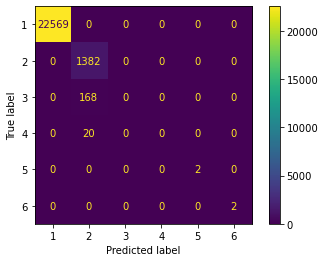

In [ ]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.tree import DecisionTreeClassifier
import sklearn.metrics as metrics
model_dt=DecisionTreeClassifier(class_weight='balanced', max_depth=3)
model_dt.fit(X_train,y_train)
y_pred = model_dt.predict(X_test)
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
from sklearn.metrics import classification_report
print('Classification Report')
print(classification_report( y_test, y_pred,labels =[1,2,3,4,5,6], target_names=['Level 1', 'Level 2', 'Level 3', 'Level 4', 'Level 5','Level 6']))
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,plot_confusion_matrix
cm=confusion_matrix(y_test, y_pred)
plot_confusion_matrix(model_dt,X_train,y_train)

In [ ]:
print(y_test.head(1))

4939    1
Name: Level, dtype: int64


In [ ]:
import warnings
warnings.filterwarnings("ignore")
print(model_dt.predict(np.array([['0','2782','2018','8.07',' 12.96  ','21.35',' 90.794096','90.5835','98.85274','2022']])))

[1]


In [ ]:
print(X_test.head())

       Country Name  City  Year  PM2.5 (μg/m3)  PM10 (μg/m3)  NO2 (μg/m3)  \
4939             19  2455  2019       54.05000     30.533252    20.619336   
7261             19  6593  2018       71.27000     30.533252    20.619336   
9075             33  5177  2014       22.92032     30.533252     1.870000   
25953            98  1945  2018       22.92032     14.500000    14.330000   
22404            85  3231  2018       24.98000     35.440000    21.320000   

       PM25 temporal coverage (%)  PM10 temporal coverage (%)  \
4939                    96.621005                     90.5835   
7261                    97.534247                     90.5835   
9075                    90.794096                     90.5835   
25953                   90.794096                     90.5835   
22404                   90.794096                     90.5835   

       NO2 temporal coverage (%)  Updated Year  
4939                   93.696804          2022  
7261                   93.696804          2022  

In [ ]:
print(cm)

[[7562    0    0    0    0]
 [   0  435    0    0    0]
 [   0   47    0    0    0]
 [   0    2    0    0    0]
 [   0    0    0    0    2]]


In [ ]:
print(y_test,y_pred)

4939     1
7261     1
9075     1
25953    1
22404    1
        ..
2690     1
30642    1
13798    1
12       1
21133    1
Name: Level, Length: 8048, dtype: int64 [1 1 1 ... 1 1 1]


Accuracy: 0.9913021868787276
Classification Report
              precision    recall  f1-score   support

     Level 1       1.00      1.00      1.00      7562
     Level 2       0.89      0.96      0.92       435
     Level 3       0.00      0.00      0.00        47
     Level 4       0.00      0.00      0.00         2
     Level 5       0.00      0.00      0.00         0
     Level 6       0.00      0.00      0.00         2

   micro avg       0.99      0.99      0.99      8048
   macro avg       0.31      0.33      0.32      8048
weighted avg       0.99      0.99      0.99      8048



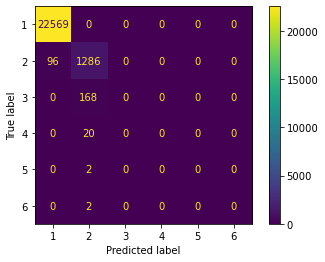

In [ ]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LogisticRegression
import sklearn.metrics as metrics

logreg = LogisticRegression(random_state=42, solver = 'liblinear')
logreg_model = logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
print('Classification Report')
print(classification_report(y_test, y_pred, labels =[1,2,3,4,5,6], target_names=['Level 1', 'Level 2', 'Level 3', 'Level 4', 'Level 5','Level 6']))
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,plot_confusion_matrix
cm=confusion_matrix(y_test, y_pred)
plot_confusion_matrix(logreg,X_train,y_train)

Accuracy: 0.9993787276341949
Classification Report
              precision    recall  f1-score   support

     Level 1       1.00      1.00      1.00      7562
     Level 2       1.00      1.00      1.00       435
     Level 3       0.92      0.98      0.95        47
     Level 4       0.00      0.00      0.00         2
     Level 5       0.00      0.00      0.00         0
     Level 6       0.00      0.00      0.00         2

   micro avg       1.00      1.00      1.00      8048
   macro avg       0.49      0.50      0.49      8048
weighted avg       1.00      1.00      1.00      8048



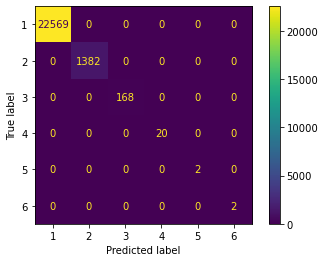

In [ ]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestClassifier
import sklearn.metrics as metrics
model_rf=RandomForestClassifier(random_state=1, n_estimators=10)
model_rf.fit(X_train,y_train)
y_pred = model_rf.predict(X_test)
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
print('Classification Report')
print(classification_report(y_test, y_pred, labels =[1,2,3,4,5,6], target_names=['Level 1', 'Level 2', 'Level 3', 'Level 4', 'Level 5','Level 6']))
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,plot_confusion_matrix
cm=confusion_matrix(y_test, y_pred)
plot_confusion_matrix(model_rf,X_train,y_train)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,plot_confusion_matrix
cm=confusion_matrix(y_test, y_pred)

In [ ]:
print(' traing set score: {:.4f}'.format(logreg.score(X_train,y_train)))
print(' traing set score: {:.4f}'.format(logreg.score(X_test,y_test)))

 traing set score: 0.9881
 traing set score: 0.9913


Accuracy: 0.9553926441351889
Classification Report
              precision    recall  f1-score   support

     Level 1       1.00      0.96      0.98      7562
     Level 2       0.56      0.90      0.69       435
     Level 3       0.80      0.94      0.86        47
     Level 4       0.33      1.00      0.50         2
     Level 5       0.00      0.00      0.00         0
     Level 6       0.00      0.00      0.00         2

   micro avg       0.96      0.96      0.96      8048
   macro avg       0.45      0.63      0.50      8048
weighted avg       0.97      0.96      0.96      8048



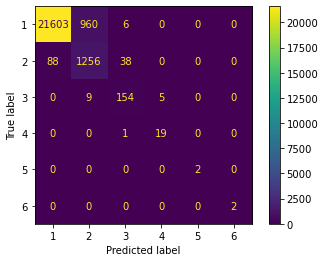

In [ ]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.naive_bayes import GaussianNB
import sklearn.metrics as metrics
classifier= GaussianNB()
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
print('Classification Report')
print(classification_report(y_test, y_pred, labels =[1,2,3,4,5,6], target_names=['Level 1', 'Level 2', 'Level 3', 'Level 4', 'Level 5','Level 6']))
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,plot_confusion_matrix
cm=confusion_matrix(y_test, y_pred)
plot_confusion_matrix(classifier,X_train,y_train)

Accuracy: 0.9993787276341949
Classification Report
              precision    recall  f1-score   support

     Level 1       1.00      1.00      1.00      7562
     Level 2       1.00      1.00      1.00       435
     Level 3       1.00      0.98      0.99        47
     Level 4       0.50      1.00      0.67         2
     Level 5       0.00      0.00      0.00         0
     Level 6       0.00      0.00      0.00         2

   micro avg       1.00      1.00      1.00      8048
   macro avg       0.58      0.66      0.61      8048
weighted avg       1.00      1.00      1.00      8048



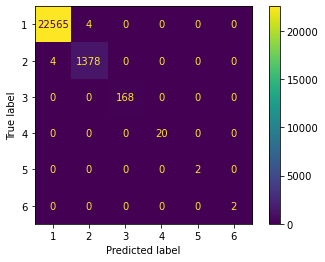

In [ ]:
import warnings
warnings.filterwarnings("ignore")
from sklearn import svm

clf_svm = svm.SVC(C=1,kernel='linear')

clf_svm.fit(X_train, y_train)

y_pred = clf_svm.predict(X_test)
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
print('Classification Report')
print(classification_report(y_test, y_pred, labels =[1,2,3,4,5,6], target_names=['Level 1', 'Level 2', 'Level 3', 'Level 4', 'Level 5','Level 6']))
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,plot_confusion_matrix
cm=confusion_matrix(y_test, y_pred)
plot_confusion_matrix(clf_svm,X_train,y_train)